In [ ]:
# --- project bootstrap (added during repo consolidation) ---
# Resolves the project root so the notebook runs from notebooks/ or from the repo root,
# and puts src/ on sys.path so `import laptop_price` works.
import os, sys, pathlib

_here = pathlib.Path.cwd()
for _cand in (_here, *_here.parents):
    if (_cand / "pyproject.toml").exists():
        PROJECT_ROOT = _cand
        break
else:
    raise RuntimeError("pyproject.toml not found - run this notebook inside the repo")

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))
print(f"project root: {PROJECT_ROOT}")


# Model-Ready Dataset Creation

This notebook transforms preprocessed laptop data into a **model-ready format** for machine learning. The pipeline covers:

- **Feature Encoding**: Converting categorical variables (CPU, GPU, model names) to numerical representations
- **RAM & Storage Processing**: Extracting DDR generation from RAM types, encoding storage configurations
- **Condition (Etat) Encoding**: Ordinal encoding based on price correlation with inference for missing values
- **Feature Selection**: Dropping redundant columns while preserving predictive power
- **Correlation Analysis**: Final heatmap to visualize feature relationships with price


## Libraries

**Imports essential packages for data manipulation and analysis.**
- `pandas` and `numpy` for data processing and numerical operations
- `re` for regular expression pattern matching in text extraction


In [25]:
import numpy as np
import pandas as pd
import csv
import os
import re
from rapidfuzz import process, fuzz
import seaborn as sns
import matplotlib.pyplot as plt

## Data Loading

**Loads the preprocessed laptop dataset from the previous notebook.**
- Source file: `laptops_after_preprocessing.csv` containing cleaned laptop specifications
- Dataset includes CPU/GPU benchmarks, RAM/storage sizes, screen specs, and pricing data


In [26]:
IN = "data/processed/pre_processed_data.csv"
OUT = "data/processed/model_ready_data.csv"
df = pd.read_csv(IN)

## Encoding and Cleaning

**Selects and prepares columns for the final model-ready dataset.**
- Filters dataset to include only relevant features for price prediction
- Retains key specifications: CPU/GPU metrics, RAM/storage, screen attributes
- Removes temporary or preprocessing-specific columns


In [27]:
#keep only necessary columns
#replace df["price_preview"] with df["price_corrected"]
df["price_preview"] = df["price_corrected"]
df.drop(columns=["price_corrected"], inplace=True)
df = df[
    [ 'price_preview', 'created_at', 'spec_Etat', 'model_name',
       'RAM_SIZE', 'SSD_SIZE', 'HDD_SIZE',
       'SCREEN_SIZE', 'SCREEN_RESOLUTION', 'RAM_TYPE', 'mapped_cpu_name',
       'cores', 'cpu_mark', 'tdp', 'gpu_name',
       'gpu_g3d_mark', 'gpu_g2d_mark', 'gpu_tdp',
       'SCREEN_SIZE_SNAPPED', 'SCREEN_RESOLUTION_STD', 'SCREEN_RESOLUTION_ENC',
         'cpu_generation_normalized'
    ]
]
df.columns


Index(['price_preview', 'created_at', 'spec_Etat', 'model_name', 'RAM_SIZE',
       'SSD_SIZE', 'HDD_SIZE', 'SCREEN_SIZE', 'SCREEN_RESOLUTION', 'RAM_TYPE',
       'mapped_cpu_name', 'cores', 'cpu_mark', 'tdp', 'gpu_name',
       'gpu_g3d_mark', 'gpu_g2d_mark', 'gpu_tdp', 'SCREEN_SIZE_SNAPPED',
       'SCREEN_RESOLUTION_STD', 'SCREEN_RESOLUTION_ENC',
       'cpu_generation_normalized'],
      dtype='object')

### Price Column Update

**Replaces `price_preview` with corrected prices from preprocessing.**
- Uses `price_corrected` values to replace original `price_preview` column
- Drops the redundant `price_corrected` column after transfer
- Selects only the model-relevant columns for further processing


## CPU & GPU Processing

**Handles CPU and GPU data for encoding and feature engineering.**
- CPU names mapped to benchmark scores (`cpu_mark`) and specifications
- GPU names processed similarly with G3D/G2D marks for performance metrics
- TDP (Thermal Design Power) values included as efficiency indicators


In [28]:
#let's print the cpu names of the null gpu_g3d_mark rows
print(df[df["gpu_g3d_mark"].isna()]["mapped_cpu_name"])

17       NaN
21       NaN
41       NaN
45       NaN
53       NaN
        ... 
16379    NaN
16380    NaN
16381    NaN
16386    NaN
16387    NaN
Name: mapped_cpu_name, Length: 661, dtype: object


In [29]:
# Drop rows with missing CPU mapping

df = df.dropna(subset=['mapped_cpu_name'])



# Safe GPU lookup helper to avoid IndexError when GPU is missing in gpus.csv

df_gpus = pd.read_csv("data/raw/gpus.csv")



def safe_gpu_info(gpu_name):

    match = df_gpus[df_gpus['gpu_name'] == gpu_name]

    if match.empty:

        print(f"[warn] GPU '{gpu_name}' not found in gpus.csv; leaving g3d/g2d/tdp as NaN")

        return {"g3d_mark": np.nan, "g2d_mark": np.nan, "tdp(w)": np.nan}

    row = match.iloc[0]

    return {"g3d_mark": row['g3d_mark'], "g2d_mark": row['g2d_mark'], "tdp(w)": row['tdp(w)']}



# Fill Intel GMA 4500MHD (only where CPU matches the old Celeron pattern)

gma_info = safe_gpu_info('Intel GMA 4500MHD')

df.loc[

    (df['mapped_cpu_name'].str.contains('Celeron Dual-Core T3')) & (df['gpu_name'] == 'Intel GMA 4500MHD'),

    ['gpu_g3d_mark', 'gpu_g2d_mark', 'gpu_tdp']

] = [gma_info['g3d_mark'], gma_info['g2d_mark'], gma_info['tdp(w)']]



# Fill VIA Chrome9

via_info = safe_gpu_info('VIA Chrome9')

df.loc[

    (df['gpu_name'] == 'VIA Chrome9'),

    ['gpu_g3d_mark', 'gpu_g2d_mark', 'gpu_tdp']

] = [via_info['g3d_mark'], via_info['g2d_mark'], via_info['tdp(w)']]



# Drop rows with the problematic Atom CPU

df = df[~df['mapped_cpu_name'].str.contains('Intel Atom C2338 @ 1.74GHz')]



print(df['cpu_mark'].isna().sum())

# Re-map cpu_mark just in case

df_cpu = pd.read_csv("data/raw/cpus.csv")

def get_cpu_mark(cpu_name):

    match = df_cpu[df_cpu['name'] == cpu_name]

    if not match.empty:

        return match.iloc[0]['cpumark']

    else:

        return np.nan

df['cpu_mark'] = df['mapped_cpu_name'].apply(get_cpu_mark)



df['gpu_g3d_mark'] = df['gpu_g3d_mark'].str.replace(',', '')

df['gpu_g3d_mark'] = pd.to_numeric(df['gpu_g3d_mark'], errors='coerce')



df['gpu_g2d_mark'] = df['gpu_g2d_mark'].str.replace(',', '')

df['gpu_g2d_mark'] = pd.to_numeric(df['gpu_g2d_mark'], errors='coerce')



df['cpu_mark'] = df['cpu_mark'].str.replace(',', '')

df['cpu_mark'] = pd.to_numeric(df['cpu_mark'], errors='coerce')



# Print diagnostics

print(df[df['gpu_g3d_mark'].isna()][['model_name', 'mapped_cpu_name', 'gpu_name']])

print('###################')

print(df[df['gpu_name'].isna()][['model_name', 'mapped_cpu_name']])

print(df['cpu_mark'].isna().sum())


0
Empty DataFrame
Columns: [model_name, mapped_cpu_name, gpu_name]
Index: []
###################
Empty DataFrame
Columns: [model_name, mapped_cpu_name]
Index: []
0


### GPU Mark Cleaning & Type Conversion

**Cleans and converts GPU/CPU benchmark values to numeric format.**
- Removes comma separators from benchmark strings (e.g., '15,000' → '15000')
- Converts `gpu_g3d_mark`, `gpu_g2d_mark`, and `cpu_mark` to numeric types
- Handles edge cases for missing GPUs (Intel GMA 4500MHD, VIA Chrome9)


In [30]:
df_gpus = pd.read_csv("data/raw/gpus.csv")

### Data Type Verification

**Verifies column data types after encoding transformations.**
- Confirms all benchmark columns are now numeric (float64/int64)
- Ensures proper encoding of screen resolution and size
- Validates CPU generation normalization values


In [31]:

df.dtypes

price_preview                float64
created_at                    object
spec_Etat                     object
model_name                    object
RAM_SIZE                      object
SSD_SIZE                      object
HDD_SIZE                      object
SCREEN_SIZE                  float64
SCREEN_RESOLUTION             object
RAM_TYPE                      object
mapped_cpu_name               object
cores                        float64
cpu_mark                       int64
tdp                          float64
gpu_name                      object
gpu_g3d_mark                   int64
gpu_g2d_mark                   int64
gpu_tdp                      float64
SCREEN_SIZE_SNAPPED          float64
SCREEN_RESOLUTION_STD         object
SCREEN_RESOLUTION_ENC        float64
cpu_generation_normalized    float64
dtype: object

## Model Name Processing

**Encodes laptop model families into numerical categories.**
- Extracts brand-specific model series (e.g., ThinkPad, MacBook, Inspiron)
- Converts categorical model names to integer encoding for ML compatibility
- Preserves model hierarchy information for price prediction


Unique models in data: 47
['IDEAPAD' 'AERO' 'STEALTH' 'ROG' nan 'XPS' 'THINKPAD' 'LATITUDE' 'SWORD'
 'PAVILION' 'ELITEBOOK' 'VIVOBOOK' 'PROBOOK' 'ASPIRE' 'MACBOOK' 'VECTOR'
 'INSPIRON' 'NITRO' 'OMEN' 'ALIENWARE' 'TUF' 'GALAXY' 'ZBOOK' 'SURFACE'
 'BLADE' 'LEGION' 'MAC' 'ZENBOOK' 'PRECISION' 'YOGA' 'PREDATOR' 'STRIX'
 'IMAC' 'KATANA' 'VICTUS' 'ENVY' 'SPECTRE' 'THINKBOOK' 'TRAVELMATE' 'GF'
 'VOSTRO' 'SWIFT' 'SPIN' 'OPTIPLEX' 'DYNABOOK' 'TRANSFORMER' 'COMPAQ']


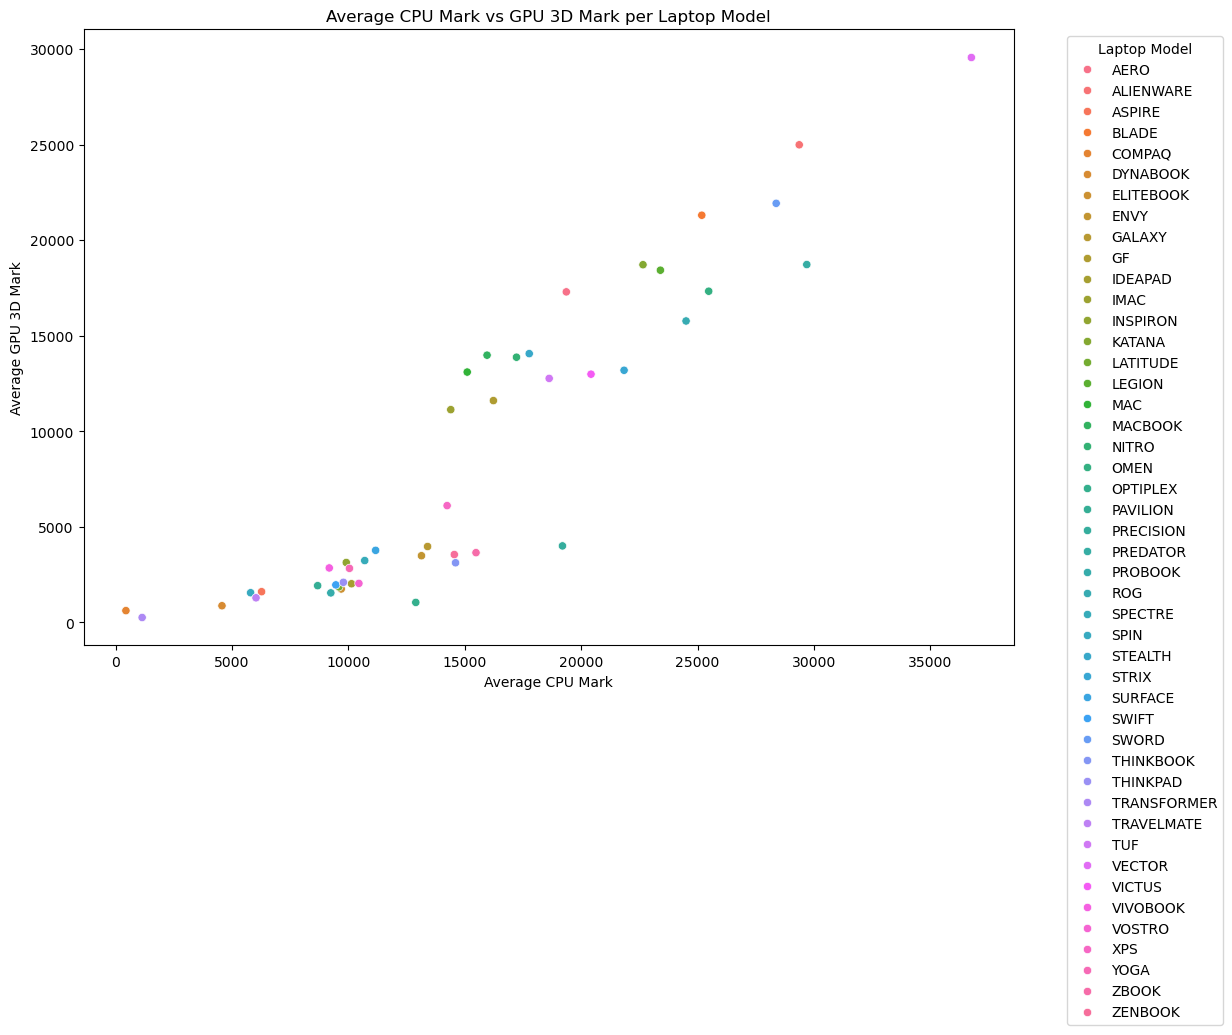

Model family distribution after encoding:
model_family
0      502
1    11800
2     3126
3      161
Name: count, dtype: int64
0


In [32]:
#get the unique value of models in data
unique_models = df['model_name'].unique()
print(f"Unique models in data: {len(unique_models)}")
print(unique_models)
# Convert cpu_mark and gpu_g3d_mark to numeric
#let's plot the average cpu and gpu mark per model maybe we can create some families of models as a feature


model_cpu_gpu_marks = df.groupby('model_name').agg({'cpu_mark': 'mean', 'gpu_g3d_mark': 'mean'}).reset_index()
plt.figure(figsize=(12, 8))
sns.scatterplot(data=model_cpu_gpu_marks, x='cpu_mark', y='gpu_g3d_mark', hue='model_name')
plt.title('Average CPU Mark vs GPU 3D Mark per Laptop Model')
plt.xlabel('Average CPU Mark')
plt.ylabel('Average GPU 3D Mark')
plt.legend(title='Laptop Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


# Group by model and get average CPU and GPU marks
model_performance = df.groupby('model_name').agg({'cpu_mark': 'mean', 'gpu_g3d_mark': 'mean'}).reset_index()

# Define families based on both CPU and GPU performance tiers
# Tier 0: entry (CPU 0-10k, GPU 0-4k)
# Tier 1: mid (CPU 10k-25k, GPU 4k-18k) 
# Tier 2: high-end (CPU 25k+, GPU 18k+)

def classify_model_tier(cpu_mark, gpu_mark):
    if cpu_mark >= 25000 and gpu_mark >= 18000:
        return 'high-end'
    elif cpu_mark >= 10000 and gpu_mark >= 4000:
        return 'mid'
    else:
        return 'entry'

model_performance['tier'] = model_performance.apply(lambda row: classify_model_tier(row['cpu_mark'], row['gpu_g3d_mark']), axis=1)

families = {
    'entry': model_performance[model_performance['tier'] == 'entry']['model_name'].tolist(),
    'mid': model_performance[model_performance['tier'] == 'mid']['model_name'].tolist(),
    'high-end': model_performance[model_performance['tier'] == 'high-end']['model_name'].tolist()
}
#function that given a model name returns its family
def get_model_family(model_name):
    for family, models in families.items():
        if model_name in models:
            return family
    return 'unknown'
#apply the function to create a new column 'model_family'
df['model_family'] = df['model_name'].apply(get_model_family)

# Ordinal encoding for model families based on performance tiers
def encode_model_family(family):
    """
    Encode model families using ordinal encoding:
    entry = 1 (lowest performance)
    mid = 2 (medium performance)
    high-end = 3 (highest performance)
    unknown = 0 (unmapped/unknown)
    """
    encoding_map = {
        'entry': 1,
        'mid': 2,
        'high-end': 3,
        'unknown': 0
    }
    return encoding_map.get(family, 0)

# Apply ordinal encoding to model_family
df['model_family_encoded'] = df['model_family'].apply(encode_model_family)

# Drop the original string column and rename the encoded one
df = df.drop(columns=['model_family', 'model_name'])
df.rename(columns={'model_family_encoded': 'model_family'}, inplace=True)

print(f"Model family distribution after encoding:")
print(df['model_family'].value_counts().sort_index())
print(df['cpu_mark'].isna().sum())

### Model Family Classification

**Groups laptop models into performance tiers based on CPU/GPU benchmarks.**
- **Entry Tier**: CPU < 10k, GPU < 4k (budget laptops)
- **Mid Tier**: CPU 10k-25k, GPU 4k-18k (mainstream laptops)
- **High-End Tier**: CPU ≥ 25k, GPU ≥ 18k (premium/gaming laptops)
- Applies ordinal encoding: entry=1, mid=2, high-end=3, unknown=0


## Price

In [33]:
## let's investigate rows with price_preview as NaN
nan_price_rows = df[df['price_preview'].isna()]
print(nan_price_rows[['mapped_cpu_name', 'gpu_name', 'cpu_mark', 'gpu_g3d_mark']])
#we drop them
df = df.dropna(subset=['price_preview'])

                      mapped_cpu_name                gpu_name  cpu_mark  \
15750         Intel Core Ultra 9 185H        GeForce RTX 4080     29315   
15751         Intel Core Ultra 7 258V      Intel Arc Graphics     18945   
15752         Intel Core Ultra 7 155U      Intel Arc Graphics     16169   
15753         Intel Core Ultra 7 155H        GeForce RTX 4060     24673   
15754             Intel Core i7-1260P  Intel UHD Graphics 770     16583   
...                               ...                     ...       ...   
15820  Intel Core i5-1135G7 @ 2.40GHz  Intel Iris Xe Graphics      9399   
15821  Intel Core i5-1135G7 @ 2.40GHz  Intel Iris Xe Graphics      9399   
15822  Intel Core i7-10870H @ 2.20GHz        GeForce GTX 1660     14031   
15823  Intel Core i7-10870H @ 2.20GHz        GeForce RTX 2060     14031   
15824  Intel Core i7-10510U @ 1.80GHz      Intel UHD Graphics      6394   

       gpu_g3d_mark  
15750         34449  
15751          5440  
15752          5440  
15753      

## RAM And Storage

In [34]:
def extract_ram_size_gb(ram_str):
    """Extract RAM size in GB from string like '16GB', '512MB'"""
    if pd.isna(ram_str):
        return np.nan
    ram_str = str(ram_str).upper()
    
    # Handle GB
    if 'GB' in ram_str:
        try:
            return float(ram_str.replace('GB', '').strip())
        except:
            return np.nan
    # Handle MB (convert to GB)
    elif 'MB' in ram_str:
        try:
            return float(ram_str.replace('MB', '').strip()) / 1024
        except:
            return np.nan
    return np.nan

def extract_storage_gb(storage_str):
    """Extract storage size in GB"""
    if pd.isna(storage_str):
        return 0
    storage_str = str(storage_str).upper()
    
    # Handle TB
    if 'TB' in storage_str:
        try:
            return float(storage_str.replace('TB', '').strip()) * 1024
        except:
            return 0
    # Handle GB
    elif 'GB' in storage_str:
        try:
            return float(storage_str.replace('GB', '').strip())
        except:
            return 0
    return 0


df['RAM_SIZE'] = df['RAM_SIZE'].apply(extract_ram_size_gb)
df['SSD_SIZE'] = df['SSD_SIZE'].apply(extract_storage_gb)
df['HDD_SIZE'] = df['HDD_SIZE'].apply(extract_storage_gb)

#SSD_SIZE = Nan -> 0
df['SSD_SIZE'] = df['SSD_SIZE'].fillna(0)
#HDD_SIZE = Nan -> 0
df['HDD_SIZE'] = df['HDD_SIZE'].fillna(0)

ram_type_mapping = {
    # Legacy types
    'SDRAM': 0.5,      # Very old
    'DDR': 1,          # DDR1
    'DDR2': 1.5,       # DDR2
    'DDR3': 2,         # DDR3
    'DDR3L': 2,        # DDR3 Low voltage
    'LPDDR3': 2,       # Low power DDR3
    
    # Current mainstream
    'DDR4': 3,         # DDR4
    'DDR4X': 3.2,      # DDR4X (slightly faster)
    'LPDDR4': 3,       # Low power DDR4
    'LPDDR4X': 3.2,    # Low power DDR4X
    
    # Latest generation
    'DDR5': 4,         # DDR5
    'DDR5X': 4.2,      # DDR5X (faster)
    'LPDDR5': 4,       # Low power DDR5
    'LPDDR5X': 4.2,    # Low power DDR5X (fastest mobile)
    
    
    # Apple Unified Memory (similar to LPDDR5 performance)
    'Unified': 4,      # Apple Unified Memory - high performance
    
    # Generic/Mixed
    'DDR4/DDR5': 3.5,  # Mixed compatibility
    'LPDDR': 2.5,      # Generic LPDDR (assume mid)
}

def encode_ram_type(ram_type_str):
    """Encode RAM type to ordinal value"""
    if pd.isna(ram_type_str):
        return np.nan
    ram_str = str(ram_type_str).strip()
    
    # Direct match first
    if ram_str in ram_type_mapping:
        return ram_type_mapping[ram_str]
    
    # Try uppercase match
    ram_upper = ram_str.upper().replace(' ', '')
    for key, value in ram_type_mapping.items():
        if key.upper() == ram_upper or key.upper() in ram_upper:
            return value
    
    return np.nan  # Unknown type

df['ram_type_encoded'] = df['RAM_TYPE'].apply(encode_ram_type)
#lets print the indices of the rows where ram_size is null
missing_ram_indices = df[df['RAM_SIZE'].isna()].index.tolist()

In [35]:
cpu_ram_mapping = {
    "Intel Core i5-8250U @ 1.60GHz": 8,
    "Apple M3 Max 14 Core": 32,
    "Apple M4 Pro 12 Core": 18,
    "Apple M4 10 Core": 16,
    "Intel Core i7-4712HQ @ 2.30GHz": 8,
    "Intel Core i7-1250U": 16,
    "Intel Core i7-1165G7 @ 2.80GHz": 16,
    "Intel Core i7-1185G7 @ 3.00GHz": 16,
    "Intel Core i5-1135G7 @ 2.40GHz": 16,
    "Intel Core i5-6200U @ 2.30GHz": 8,
    "Intel Pentium N4200 @ 1.10GHz": 4,
    "Intel Core i3-1005G1 @ 1.20GHz": 8,
    "Intel Core i3-370M @ 2.40GHz": 4,
    "Celeron Dual-Core T3000 @ 1.80GHz": 2,
    "Apple M3 8 Core": 24,
    "Intel Core i3-2350M @ 2.30GHz": 4,
}

# Fill missing RAM sizes based on CPU name for the missing indices
for idx in missing_ram_indices:
    cpu_name = df.at[idx, 'mapped_cpu_name'] if idx in df.index else None
    if pd.isna(df.at[idx, 'RAM_SIZE']) and cpu_name in cpu_ram_mapping:
        df.at[idx, 'RAM_SIZE'] = cpu_ram_mapping[cpu_name]
        print(f"Index {idx}: Set RAM size to {cpu_ram_mapping[cpu_name]}GB")

# Check how many nulls remain
print(f"\nRemaining null RAM sizes: {df['RAM_SIZE'].isna().sum()}")
print(f"Total rows with RAM info: {(~df['RAM_SIZE'].isna()).sum()}")

# Verify the mappings worked
print("\nVerification of mapped values:")
for cpu_name, ram_size in cpu_ram_mapping.items():
    matches = df.index[(df['mapped_cpu_name'] == cpu_name) & (df['RAM_SIZE'] == ram_size)].tolist()
    if matches:
        print(f"{cpu_name} -> {ram_size}GB (rows: {matches})")

df.drop(columns=['RAM_TYPE'], inplace=True)
df.rename(columns={'ram_type_encoded': 'RAM_TYPE'}, inplace=True)

Index 27: Set RAM size to 8GB
Index 56: Set RAM size to 32GB
Index 97: Set RAM size to 32GB
Index 112: Set RAM size to 18GB
Index 188: Set RAM size to 18GB
Index 342: Set RAM size to 16GB
Index 4819: Set RAM size to 8GB
Index 5603: Set RAM size to 16GB
Index 6377: Set RAM size to 16GB
Index 6910: Set RAM size to 16GB
Index 10238: Set RAM size to 8GB
Index 12123: Set RAM size to 16GB
Index 12828: Set RAM size to 16GB
Index 14477: Set RAM size to 8GB
Index 14865: Set RAM size to 4GB
Index 15334: Set RAM size to 8GB
Index 15439: Set RAM size to 4GB
Index 15458: Set RAM size to 2GB
Index 15745: Set RAM size to 16GB
Index 16067: Set RAM size to 24GB
Index 16170: Set RAM size to 4GB

Remaining null RAM sizes: 0
Total rows with RAM info: 15517

Verification of mapped values:
Intel Core i5-8250U @ 1.60GHz -> 8GB (rows: [19, 27, 43, 61, 135, 286, 402, 2770, 4754, 5726, 5908, 6139, 6247, 6248, 6919, 7060, 7061, 7364, 7558, 7695, 7782, 7861, 7863, 7864, 8328, 8398, 8495, 8663, 9034, 9035, 9036, 9

## SCREEN

In [36]:
df.dtypes
df.drop(columns=['SCREEN_SIZE', 'SCREEN_RESOLUTION', 'SCREEN_RESOLUTION_STD'], inplace=True)

In [37]:
#fill SCREEN_SIZE_SNAPPED NaN with the median
df['SCREEN_SIZE_SNAPPED'] = df['SCREEN_SIZE_SNAPPED'].fillna(df['SCREEN_SIZE_SNAPPED'].median())
df['SCREEN_RESOLUTION_ENC'] = df['SCREEN_RESOLUTION_ENC'].fillna(df['SCREEN_RESOLUTION_ENC'].mode()[0])

In [38]:
df.isna().sum()


price_preview                   0
created_at                      0
spec_Etat                    6437
RAM_SIZE                        0
SSD_SIZE                        0
HDD_SIZE                        0
mapped_cpu_name                 0
cores                           0
cpu_mark                        0
tdp                             0
gpu_name                        0
gpu_g3d_mark                    0
gpu_g2d_mark                    0
gpu_tdp                         0
SCREEN_SIZE_SNAPPED             0
SCREEN_RESOLUTION_ENC           0
cpu_generation_normalized     607
model_family                    0
RAM_TYPE                        0
dtype: int64

### Missing Value Analysis

**Checks for remaining missing values after encoding.**
- Identifies columns that still contain NaN values
- Key columns with missing data: RAM_SIZE (20), GPU marks (14), cpu_generation (566)
- These will be handled before model training


## Etat

In [39]:
# Let's examine the spec_Etat feature more thoroughly
print("Original spec_Etat value counts:")
original_etat_counts = df['spec_Etat'].value_counts(dropna=False)
print(original_etat_counts)
print(f"\nPercentage of NaN values: {df['spec_Etat'].isna().sum() / len(df) * 100:.2f}%")

unique_etat = df['spec_Etat'].unique()
print(f"Unique values in spec_Etat: {unique_etat}")

# Let's see the correlation of spec_Etat with price_preview for non-null values
etat_price_avg = df.groupby('spec_Etat')['price_preview'].mean().reset_index()
print("\nAverage prices by state:")
print(etat_price_avg)

Original spec_Etat value counts:
spec_Etat
NaN              6437
BON TAT          4832
JAMAIS UTILIS    3995
MOYEN             253
Name: count, dtype: int64

Percentage of NaN values: 41.48%
Unique values in spec_Etat: ['BON TAT' 'JAMAIS UTILIS' nan 'MOYEN']

Average prices by state:
       spec_Etat  price_preview
0        BON TAT   88700.301343
1  JAMAIS UTILIS  190083.426233
2          MOYEN   51412.367589


In [40]:
# Check available features that could help infer laptop state
print("Available columns:")
print(df.columns.tolist())
print(f"\nDataset shape: {df.shape}")

# Check specific features mentioned
features_to_check = ['RAM_TYPE', 'mapped_cpu_name', 'gpu_name', 'spec_Etat', 'price_preview', 'created_at']
for feature in features_to_check:
    if feature in df.columns:
        print(f"\n{feature} - unique values: {df[feature].nunique()}")
        if feature == 'RAM_TYPE':
            print(f"RAM types: {df[feature].unique()}")
        elif feature == 'spec_Etat':
            print(f"States: {df[feature].unique()}")
        elif feature == 'created_at':
            print(f"Date range: {df[feature].min()} to {df[feature].max()}")

Available columns:
['price_preview', 'created_at', 'spec_Etat', 'RAM_SIZE', 'SSD_SIZE', 'HDD_SIZE', 'mapped_cpu_name', 'cores', 'cpu_mark', 'tdp', 'gpu_name', 'gpu_g3d_mark', 'gpu_g2d_mark', 'gpu_tdp', 'SCREEN_SIZE_SNAPPED', 'SCREEN_RESOLUTION_ENC', 'cpu_generation_normalized', 'model_family', 'RAM_TYPE']

Dataset shape: (15517, 19)

RAM_TYPE - unique values: 10
RAM types: [4.  3.  2.  1.5 3.2 4.2 1.  2.5 0.5 3.5]

mapped_cpu_name - unique values: 642

gpu_name - unique values: 150

spec_Etat - unique values: 3
States: ['BON TAT' 'JAMAIS UTILIS' nan 'MOYEN']

price_preview - unique values: 925

created_at - unique values: 13811
Date range: 2018 11 27T08:27:31.000Z to 2025 08 11T16:34:50.000Z


## Condition (spec_Etat) Encoding

**Implements ordinal encoding for laptop condition with intelligent inference for missing values.**

### Ordinal Encoding Scheme
- **3 = JAMAIS UTILIS** (Never Used) - Highest price correlation
- **2 = BON TAT** (Good State) - Medium price correlation  
- **1 = MOYEN** (Average) - Lowest price correlation
- **0 = Unknown/NaN** - Inferred based on technical specifications

### Inference Logic for Missing Values
The `infer_laptop_state()` function predicts condition based on:
- **RAM Type**: DDR5/DDR5X (+3), DDR4/DDR4X/LPDDR4 (+2), DDR3/DDR2 (+1)
- **CPU Generation**: Latest (≥0.9: +3), Recent (≥0.7: +2), Mid (≥0.5: +1)
- **Listing Year**: 2024+ (+2), 2022+ (+1), pre-2020 (-1)
- **CPU Performance**: High mark ≥15000 (+1), Low mark <8000 (-1)


In [41]:
# Ordinal encoding for spec_Etat based on price correlation
def encode_etat_ordinal(etat_value):
    """
    Encode spec_Etat as ordinal values based on quality/price correlation
    JAMAIS UTILIS (Never Used) = 3 (highest)
    BON TAT (Good State) = 2 (medium)
    MOYEN (Average) = 1 (lowest)
    NaN = 0 (unknown, to be inferred)
    """
    if pd.isna(etat_value):
        return 0
    elif etat_value == 'JAMAIS UTILIS':
        return 3
    elif etat_value == 'BON TAT':
        return 2
    elif etat_value == 'MOYEN':
        return 1
    else:
        return 0  # Unknown values

In [42]:
# Inference logic to predict missing spec_Etat values
def infer_laptop_state(row):
    """
    Infer laptop state based on technical specifications and release dates
    Returns: 1 (MOYEN), 2 (BON TAT), or 3 (JAMAIS UTILIS)
    """
    
    # Extract features with proper type handling
    #ram type is float encoded
    ram_type = pd.to_numeric(row.get('RAM_TYPE', 0), errors='coerce')
    cpu_gen = pd.to_numeric(row.get('cpu_generation_normalized', 0), errors='coerce')
    if pd.isna(cpu_gen):
        cpu_gen = 0
    
    created_at = str(row.get('created_at', ''))
    
    cpu_mark = pd.to_numeric(row.get('cpu_mark', 0), errors='coerce')
    if pd.isna(cpu_mark):
        cpu_mark = 0
    
    price = pd.to_numeric(row.get('price_preview', 0), errors='coerce')
    if pd.isna(price):
        price = 0
    
    # Convert created_at to year for analysis
    try:
        year = int(created_at[:4]) if len(created_at) >= 4 else 2020
    except:
        year = 2020
    
    # Initialize score (higher score = better condition)
    state_score = 0
    
    # RAM Type scoring, RAM types: [4.  3.  2.  3.2 4.2 1.  1.5 2.5 0.5]
    if ram_type in ['4', '4.2']:  # DDR5 and DDR5X
        state_score += 3
    elif ram_type in ['3', '3.2', '2.5']:  # DDR4, DDR4X, LPDDR4
        state_score += 2
    elif ram_type in ['2', '1.5']:  # DDR3, DDR2
        state_score += 1
    else:  # Older or unknown types
        state_score += 0
    
    # CPU Generation scoring (higher generation = newer = better condition)
    if cpu_gen >= 0.9:  # Very latest generation
        state_score += 3
    elif cpu_gen >= 0.7:  # Recent generation  
        state_score += 2
    elif cpu_gen >= 0.5:  # Mid-range generation
        state_score += 1
    else:  # Older generation
        state_score += 0
    
    # Year-based scoring (newer listings more likely to be in better condition)
    if year >= 2024:
        state_score += 2
    elif year >= 2022:
        state_score += 1
    elif year >= 2020:
        state_score += 0
    else:
        state_score -= 1
    
    
    # CPU Performance scoring (better performance = likely newer = better condition)
    if cpu_mark >= 15000:  # High performance
        state_score += 1
    elif cpu_mark >= 8000:  # Medium performance
        state_score += 0
    else:  # Lower performance
        state_score -= 1
    
    # Convert score to state (adjust thresholds based on analysis)
    if state_score >= 7:
        return 3  # JAMAIS UTILIS
    elif state_score >= 4:
        return 2  # BON TAT
    else:
        return 1  # MOYEN

### Inference Logic for Missing spec_Etat

**Predicts missing condition values using a scoring system.**
- Scoring factors include RAM type, CPU generation, listing year, and performance
- Higher scores indicate better expected condition (JAMAIS UTILIS)
- Threshold-based classification: score ≥7 → JAMAIS UTILIS, ≥4 → BON, else → MOYEN


In [43]:
# Apply ordinal encoding to spec_Etat
df['spec_Etat_encoded'] = df['spec_Etat'].apply(encode_etat_ordinal)

#let's now recheck the correlation between spec_Etat and price_preview
print(df.groupby('spec_Etat_encoded')['price_preview'].mean())
df.drop(columns=['spec_Etat'], inplace=True)
df.rename(columns={'spec_Etat_encoded': 'spec_Etat'}, inplace=True)

spec_Etat_encoded
0    114649.250736
1     51412.367589
2     88700.301343
3    190083.426233
Name: price_preview, dtype: float64


### Apply Encoding & Verify Price Correlation

**Applies the ordinal encoding and verifies the price-condition relationship.**
- Confirms price increases with better condition: MOYEN < BON < JAMAIS UTILIS
- Drops original spec_Etat column and renames encoded column
- Average prices validate the ordinal ranking logic


In [44]:
df.isna().sum()

price_preview                  0
created_at                     0
RAM_SIZE                       0
SSD_SIZE                       0
HDD_SIZE                       0
mapped_cpu_name                0
cores                          0
cpu_mark                       0
tdp                            0
gpu_name                       0
gpu_g3d_mark                   0
gpu_g2d_mark                   0
gpu_tdp                        0
SCREEN_SIZE_SNAPPED            0
SCREEN_RESOLUTION_ENC          0
cpu_generation_normalized    607
model_family                   0
RAM_TYPE                       0
spec_Etat                      0
dtype: int64

### Missing Value Analysis

**Checks for remaining missing values after encoding.**
- Identifies columns that still contain NaN values
- Key columns with missing data: RAM_SIZE (20), GPU marks (14), cpu_generation (566)
- These will be handled before model training


## Drop Unnecessary Columns

**Removes columns that won't be used in the final model.**
- Drops: `created_at`, `mapped_cpu_name`, `gpu_name`, `cpu_generation_normalized`
- These columns are either redundant (already encoded) or not predictive
- Final dataset contains only numerical features ready for ML algorithms


In [45]:
df.drop(columns=['created_at', 'mapped_cpu_name', 'gpu_name', 'cpu_generation_normalized'], inplace=True)


### Final Column Verification

**Verifies data types of all remaining columns.**
- All columns are now numeric (float64 or int64)
- Dataset is ready for correlation analysis and ML modeling
- Total of 16 features remaining for price prediction


In [46]:
df.dtypes

price_preview            float64
RAM_SIZE                 float64
SSD_SIZE                 float64
HDD_SIZE                 float64
cores                    float64
cpu_mark                   int64
tdp                      float64
gpu_g3d_mark               int64
gpu_g2d_mark               int64
gpu_tdp                  float64
SCREEN_SIZE_SNAPPED      float64
SCREEN_RESOLUTION_ENC    float64
model_family               int64
RAM_TYPE                 float64
spec_Etat                  int64
dtype: object

## Final Correlation Heatmap

**Visualizes feature correlations with a heatmap for feature analysis.**
- Shows correlation matrix between all numerical features and price
- Helps identify most predictive features (e.g., cpu_mark, gpu_g3d_mark)
- Reveals potential multicollinearity issues between related features


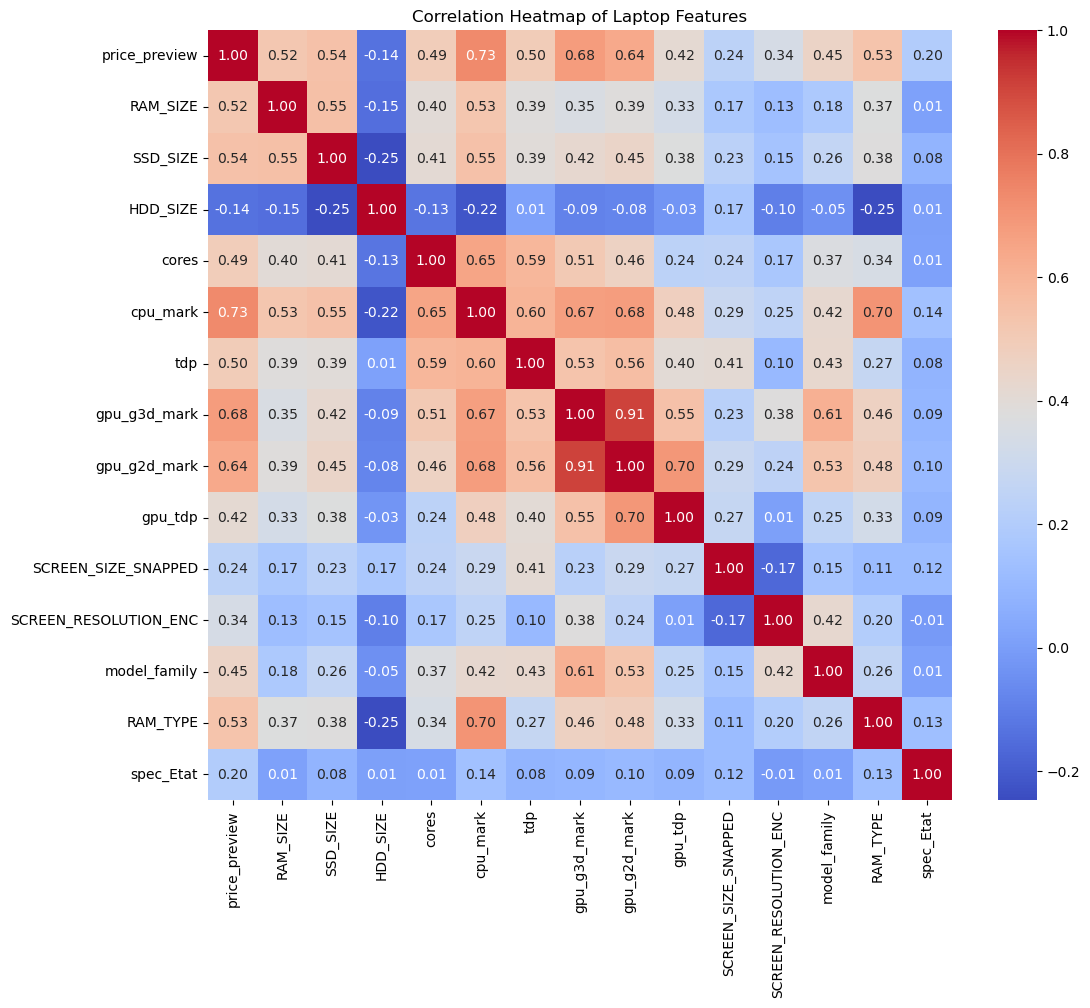

In [47]:
#final heatmap to check correlations
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Laptop Features')
plt.show()

## Export

In [48]:
#export
df.to_csv(OUT)